In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 224 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, TargetEncoder, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Global Settings --
sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [5]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


In [6]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 55.6 MB


In [7]:
train[NUMS].describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


findfont: Failed to find font weight semibold, now using 700.


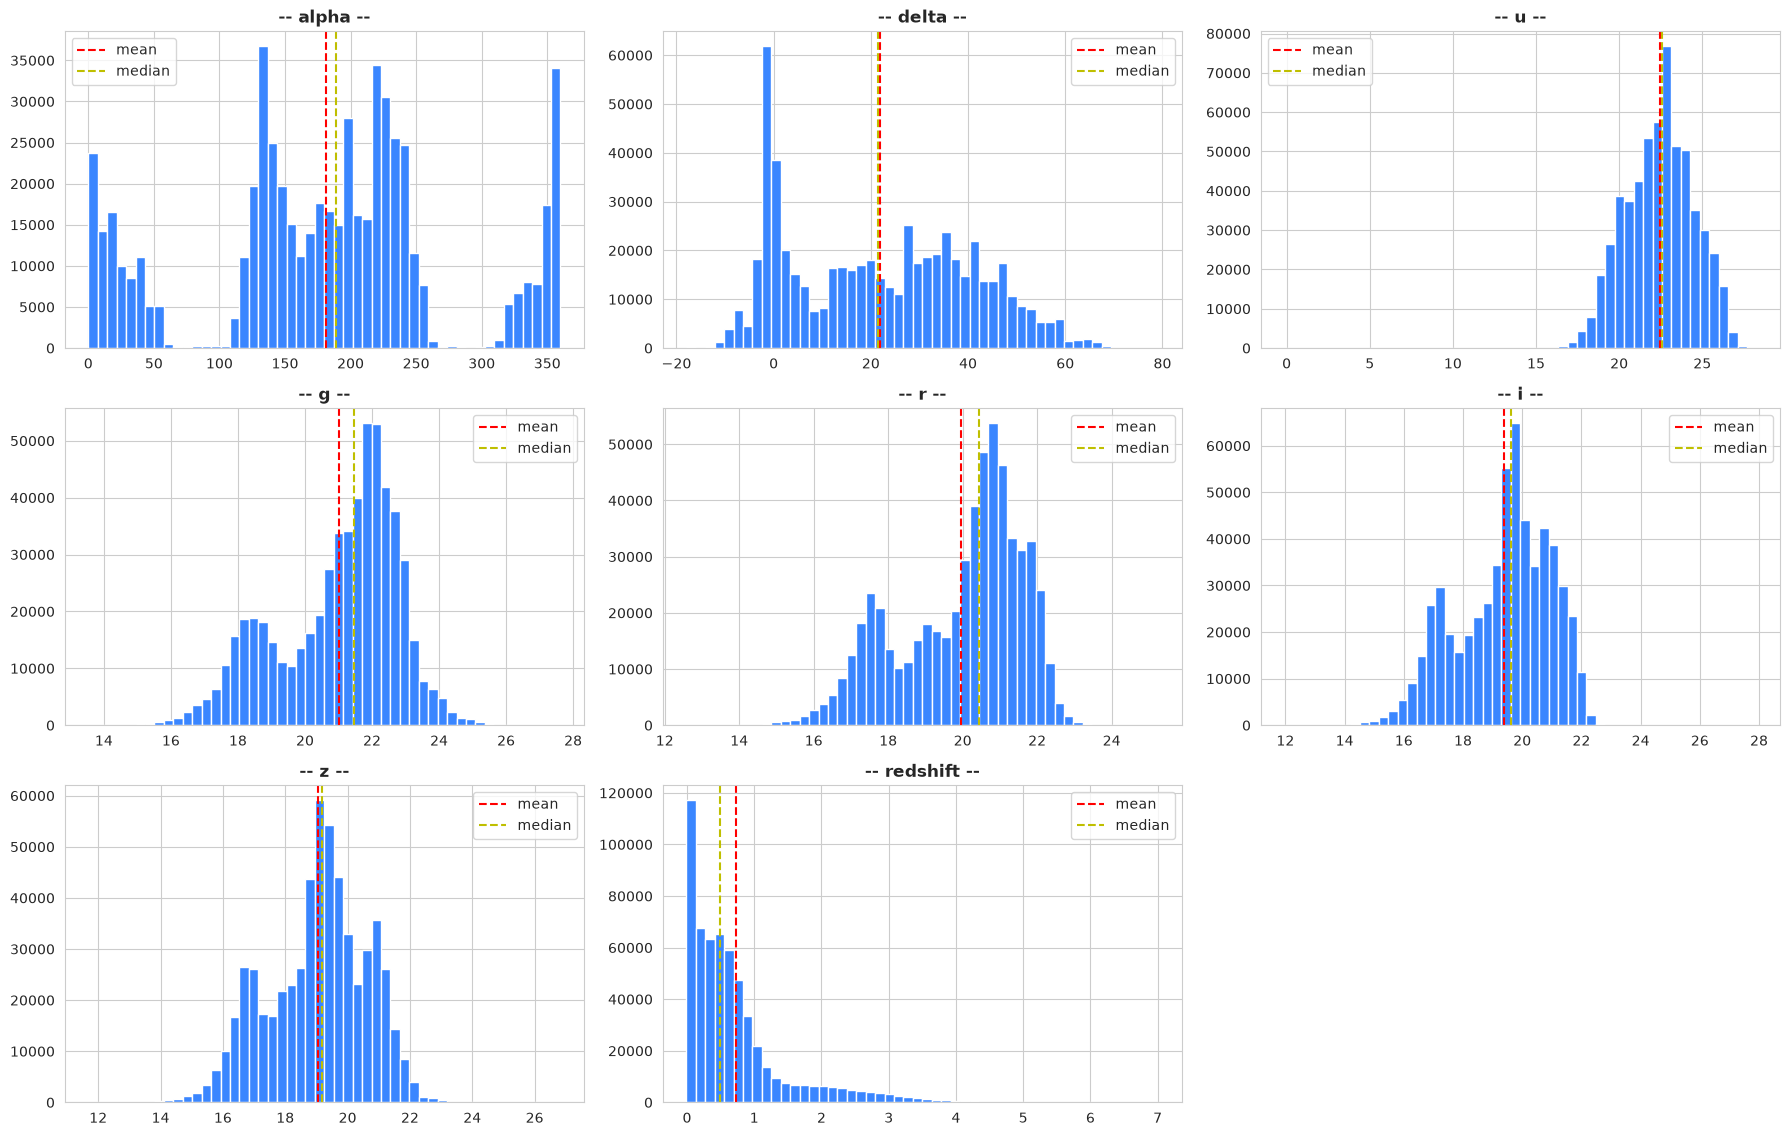

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'-- {col} --', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

galaxy_population         2
spectral_type             4
alpha                439819
delta                444062
redshift             573975
r                    577347
g                    577347
u                    577347
z                    577347
i                    577347
dtype: int64

In [11]:
def get_class_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> {label: weight}
    """
    if opt != 'auto':
        return opt
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        return dict(zip([str(c) for c in cls_], wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        class_weights = dict(zip(cls_, wts_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [12]:
get_class_weights(train[TARGET], train[TARGET])

{'0': np.float64(0.5098256861290664),
 '1': np.float64(1.642855313591081),
 '2': np.float64(2.326398626758861)}

## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# _extract_cols = ['Cumulative_Degradation', 'LapTime (s)'] # , 'LapTime_Delta'

# print(f"\nRounding... ", end='')
# for col in _extract_cols:
#     for r in range(-2, 3):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [15]:
# _extract_cols = ['RaceProgress'] # , 'LapTime_Delta'

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [0, -1]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [-1, 0]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     print(f"\nCreating value-based E_BINS... ", end='')
#     for b in [5]:
#         b_n = f'{col}_bin_{b}'
#         print(b_n+', ', end='')
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [5]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
# ## -- Arithmetic interaction --
# # u - g, g - r, r - i, i - z

# # ('u', 'g'),
# # ('g', 'r'),
# # ('i', 'z'),
# # ('g', 'i'),
# # ('r', 'z')

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_{band}_redshift_div_"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [19]:
# ## -- Cyclical extraction --
# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [20]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# INTER

In [21]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(f"{n}.. ", end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")
# train[freq_cols].describe()

In [22]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the 
#         global mean. If 'auto', an empirical Bayes estimate is used.
        
#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping
        
#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)
        
#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]
            
#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'
                    
#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)
                    
#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()
                        
#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups
                        
#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)
                    
#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]
            
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

In [25]:
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [26]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [27]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 10


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1


In [28]:
def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED'])

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

# ML TRAINING

In [29]:
try:
    import ydf
except:
    %pip install -q -U ydf
    import ydf

print(f"YDF version: {ydf.__version__}")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


YDF version: 0.16.1


In [30]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n===== Starting Cross-Validation for {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]
    
    num_classes = y.nunique()
    
    oof_preds = np.zeros((len(X), num_classes))
    test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx+1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- Target Encoding --
        # te_cols = ROUNDS
        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

        # ## -- TE Opt1. -> Using custom script --
        # te_enc = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        # cm_enc  = CategoryMeanTransformer(cat_cols=ROUNDS)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str) #.astype('category')

        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} -")

        # ## -- To enable ydf read numerical as categories --
        # flat_features = []
        # for f in cats: 
        #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

        ## -- Build model --
        model = ydf.GradientBoostedTreesLearner(
            **params,
            label=target,
            class_weights=get_class_weights(y_train, y_train),
            # features=flat_features,   # 1. Semantic for categories goes here
            # include_all_columns=True, # 2. Include all features for training
        ).train(
            ds=pd.concat([X_train, y_train], axis=1),
            valid=pd.concat([X_valid, y_valid], axis=1),
            verbose=2
        )

        ## -- Predict on val and test sets --
        oof_preds[val_idx] = model.predict(X_valid)
        test_preds += model.predict(X_test)

        ## -- Calculate and print fold score --
        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{CFG['YELLOW']} • Fold {idx+1} score: {fold_score:.5f}{CFG['RESET']}')

        # ## -- Clean up memory --
        # del y_train, y_valid, X_test
        # gc.collect() 

    ## -- Average the test predictions
    test_preds /= kf.n_splits
    
    ## -- CV results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1}: {score:.5f}")
    
    ## -- Final out-of-fold score
    oof_score = np.round(balanced_acc(train_df[target], oof_preds), 5)
    print("-------------------------------------------------|")
    print(f"Overall score: {oof_score}")
    print(f"Average score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')
    
    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'data': pd.concat([X_valid, y_valid], axis=1), 
    }

print('⚙️⚙️ Training Function Ready ⚙️⚙️')

⚙️⚙️ Training Function Ready ⚙️⚙️


In [31]:
version_name = 'ydf_v0_'
all_model_predictions = {}

MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]
ALL_CATS = CATS # + ['Stint', 'Year']

kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])
kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [32]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
57755,218.819434,41.098809,22.887579,21.175022,19.556668,18.977441,18.468760,0.593716,M,Red_Sequence,0
467513,130.913983,23.389843,22.004053,20.884906,20.875059,20.912494,20.807225,1.466239,A/F,Blue_Cloud,1
53590,218.918237,-1.918078,19.879133,18.069553,16.768183,16.242324,15.955112,0.086661,M,Red_Sequence,0


In [33]:
# %%time

# ## -- Search HPO space for 'LOCAL' & 'BEST_FIRST_GLOBAL' --
# tuner = ydf.RandomSearchTuner(num_trials=15, automatic_search_space=False)
# # tuner.choice('num_trees', [5000, 2000])
# # tuner.choice('shrinkage', [0.02, 0.05]) 
# # tuner.choice('subsample', [0.9, 1.0])
# tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'ONE_HOT', 'RANDOM'
# # tuner.choice('l2_regularization', [0.05, 0.1, 0.2, 0.5, 1.0])

# ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
# local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
# local_subspace.choice('max_depth', [4, 6, 8])

# # ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
# global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
# global_subspace.choice('max_num_nodes', [32, 64, 128])

# # ## -- Enable ydf process numeric features as categories --
# # num_as_cat = []
# # for f in CATS:
# #     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

# ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#     task=ydf.Task.CLASSIFICATION,
#     label=TARGET, 
#     tuner=tuner,
#     num_trees=10_000,
#     shrinkage=0.1,
#     # max_depth=4,
#     # features=num_as_cat,
#     # include_all_columns=True,
#     # l2_regularization=0.15,
#     # categorical_algorithm='RANDOM',
#     early_stopping_initial_iteration=10,
#     early_stopping_num_trees_look_ahead=100,
#     random_seed=CFG.SEED, 
#     num_threads=os.cpu_count(), 
# ).train(x_sample)

# ydf_HPO_model.describe()

In [34]:
# ydf_HPO_model.evaluate(x_sample2)

In [35]:
# ydf_HPO_model.plot_tree()

In [36]:
# optimizer_logs = ydf_HPO_model.hyperparameter_optimizer_logs()
# print("Total number of trials:", len(optimizer_logs.trials))

# # # Accessing the first trial
# # first_trial = optimizer_logs.trials[0]
# # print(f"\nFirst Trial Score (absolute): {abs(first_trial.score):.4f}")
# # print("First Trial Parameters:")
# # for param, value in first_trial.params.items():
# #     print(f"  {param}: {value}")

# # Iterate through all trials to find the best one (smallest absolute score)
# best_abs_score = float('inf') # Initialize to a very large number for minimization
# best_params = None

# for i, trial in enumerate(optimizer_logs.trials):
#     current_abs_score = abs(trial.score)
#     print(f"\nTrial {i+1}: Score (abs) = {current_abs_score:.5f}")
#     # print(f"  Parameters: {trial.params}") # Uncomment to see all parameters for each trial

#     if current_abs_score < best_abs_score:
#         best_abs_score = current_abs_score
#         best_params = trial.params

# print(f"\nBest Trial Score (abs): {best_abs_score:.5f}") 
# print("Best Trial Parameters:")
# if best_params:
#     for param, value in best_params.items():
#         print(f"  {param}: {value}")

# param_df = pd.Series(data=best_params, dtype='str', name='ydf_HPO_params')
# param_df.to_csv('ydf_best_params.csv', index=False)

# param_df

In [37]:
# __ = ydf.GradientBoostedTreesLearner()

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

if all_model_predictions:
    all_model_predictions.clear()

PARAMS = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': 'BEST_FIRST_GLOBAL',
    'num_trees': 10_000,
    'max_num_nodes': -1,
    'shrinkage': 0.05,
    'categorical_algorithm': 'CART', # 'CART', 'RANDOM', 'ONE_HOT'
    # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.9, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    # 'l2_regularization': 1.0,
    'early_stopping_num_trees_look_ahead': 100,
    'random_seed': CFG['SEED'],
}

for algo in ['AXIS_ALIGNED', 'SPARSE_OBLIQUE']:
    PARAMS['split_axis'] = algo
    n = version_name + 'global_' + algo.lower()
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )

[Warning] ydf.verbose(2) but logs cannot be displayed in the cell. Check colab logs or install wurlitzer with 'pip install wurlitzer'



===== Starting Cross-Validation for ydf_v0_global_axis_aligned =====

***** FOLD 1/5 - Train shape: (461877, 10) -


max_vocab_count = -1 for column class, the dictionary will not be pruned by size.


Train model on 461877 training examples and 115470 validation examples


"goss_alpha" set but "sampling_method" not equal to "GOSS".
"goss_beta" set but "sampling_method" not equal to "GOSS".
"selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
Data spec:
Number of records: 461877
Number of columns: 11

Number of columns by type:
	NUMERICAL: 8 (72.7273%)
	CATEGORICAL: 3 (27.2727%)

Columns:

NUMERICAL: 8 (72.7273%)
	1: "alpha" NUMERICAL mean:181.581 min:0.0116837 max:360 sd:96.245 dtype:DTYPE_FLOAT64
	2: "delta" NUMERICAL mean:21.8359 min:-17.967 max:79.1583 sd:18.9352 dtype:DTYPE_FLOAT64
	3: "u" NUMERICAL mean:22.4416 min:-0.139225 max:28.2533 sd:2.01822 dtype:DTYPE_FLOAT64
	4: "g" NUMERICAL mean:21.0074 min:13.5355 max:26.884 sd:1.79514 dtype:DTYPE_FLOAT64
	5: "r" NUMERICAL mean:19.9632 min:12.5794 max:25.2545 sd:1.64861 dtype:DTYPE_FLOAT64
	6: "i" NUMERICAL mean:19.3793 min:11.9628 max:27.9109 sd:1.5794 dtype:DTYPE_FLOAT64
	7: "z" NUMERICAL mean:19.0416 min:11.6828 max:26.5879 sd:1.5838 dtype:DTYPE_FLOAT64
	8: "redshift" NU

...

Train tree 579/10000 train-loss:0.057797 train-accuracy:0.982555 valid-loss:0.100478 valid-accuracy:0.963915 [total:34m57.32s iter:3.63s]


Train tree 585/10000 train-loss:0.057458 train-accuracy:0.982684 valid-loss:0.100461 valid-accuracy:0.963911 [total:35m19.04s iter:3.62s]


Model trained in 0:35:26.419417


Early stop of the training because the validation loss does not decrease anymore. Best valid-loss: 0.100415
Truncates the model to 1659 tree(s) i.e. 553  iteration(s).
Final model num-trees:553 valid-loss:0.100415 valid-accuracy:0.963933


 • Fold 5 score: 0.96393

Cross-Validation Results for ydf_v0_global_sparse_oblique
 • Fold 1: 0.96477
 • Fold 2: 0.96461
 • Fold 3: 0.96430
 • Fold 4: 0.96409
 • Fold 5: 0.96393
-------------------------------------------------|
Overall score: 0.96434
Average score: 0.96434 ± 0.00031
-------------------------------------------------|
161.16 mins


In [38]:
# ==================================================
# Base ydf_v0_global_cart | sub_0.95
# ==================================================
#  • Fold 1: 0.95881
#  • Fold 2: 0.95836
#  • Fold 3: 0.96118
#  • Fold 4: 0.96110
#  • Fold 5: 0.95991
# -------------------------------------------------|
# Overall score: 0.95987
# Average score: 0.95987 ± 0.00115
# -------------------------------------------------|
# 5.60 mins

In [39]:
# USE_FULL_TRAIN = True
# train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

# if all_model_predictions:
#     all_model_predictions.clear()

# PARAMS = {
#     'task': ydf.Task.CLASSIFICATION,
#     'growing_strategy': 'LOCAL',
#     'num_trees': 10_000,
#     'max_depth': 6,
#     'shrinkage': 0.05,
#     'categorical_algorithm': 'RANDOM', # 'CART', 'RANDOM', 'ONE_HOT'
#     # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
#     # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
#     # 'subsample': 0.95, # default RANDOM sampling
#     # 'goss_alpha': 0.2, # activates GOSS sampling
#     # 'l2_regularization': 1.0,
#     'early_stopping_num_trees_look_ahead': 100,
#     'random_seed': CFG['SEED'],
# }

# for algo in ['AXIS_ALIGNED', 'SPARSE_OBLIQUE']:
#     PARAMS['split_axis'] = algo
#     n = version_name + 'local_' + str(algo).lower()
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=ALL_CATS,
#     ) 

In [40]:
# ==================================================
# Base ydf_v0_local_random
# ==================================================
#  • Fold 1: 0.95957
#  • Fold 2: 0.95793
#  • Fold 3: 0.96015
#  • Fold 4: 0.96063
#  • Fold 5: 0.95967
# -------------------------------------------------|
# Overall score: 0.95959
# Average score: 0.95959 ± 0.00091
# -------------------------------------------------|
# 6.38 mins

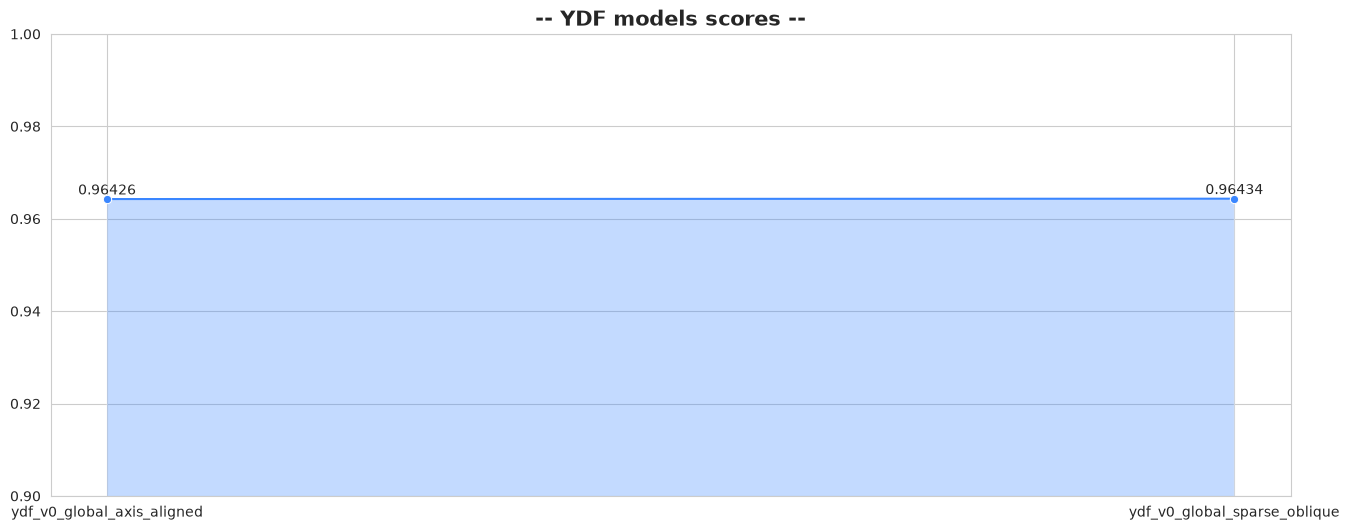

In [41]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_model_scores, marker='o')

ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.3)
ax.set_title('-- YDF models scores --', fontsize=15, fontweight='semibold')
ax.tick_params('x', rotation=0)
ax.set_ylim(0.9, 1.0)

for i, s in enumerate(all_model_scores.values()):
    ax.text(float(i), s+1e-3, s, ha='center', va='baseline')

# plt.tight_layout()
plt.show()

In [42]:
## -- Get OOF predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_model_predictions.items()):
    for key_, data_ in v.items():
        if key_ == 'oof_preds':
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f'{n} saved!')

            # ## -- Plot oof distributions --
            # _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            # CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            # axs[0].set_title(f"{n}: Calibration")

            # RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            # axs[1].set_title(f"{n}: ROC-Curve")

            # sns.histplot(data_, ax=axs[2])
            # axs[2].set_title(f"{n}: Distribution")
            
            # plt.tight_layout()
            # plt.show()

            print()

ydf_v0_global_axis_aligned_96426 saved!

ydf_v0_global_sparse_oblique_96434 saved!



In [43]:
# fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# for ax, preds, title, color in [
#     (axes[0], base_preds, f'{base_n_1}', '#73D2DE'),
#     # (axes[1], calib_preds, f'Calibrated: {cal_n_1}', '#FB5607'),
# ]:

# counts = [np.sum(preds == i) for i in range(len(np.unique(y)))]
# axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
# axs[0].set_title(f"{k}_classes")
# axs[0].set_ylabel('Count')

# for i, c in enumerate(counts):
#     axs[0].text(i, c + 2500, str(c), ha='center', fontsize=10)

# plt.suptitle('Label predictions', fontsize=15, y=1.00, fontweight='semibold')

# plt.tight_layout()
# plt.show()

ydf_v0_global_axis_aligned_96426 saved! (247435, 3)


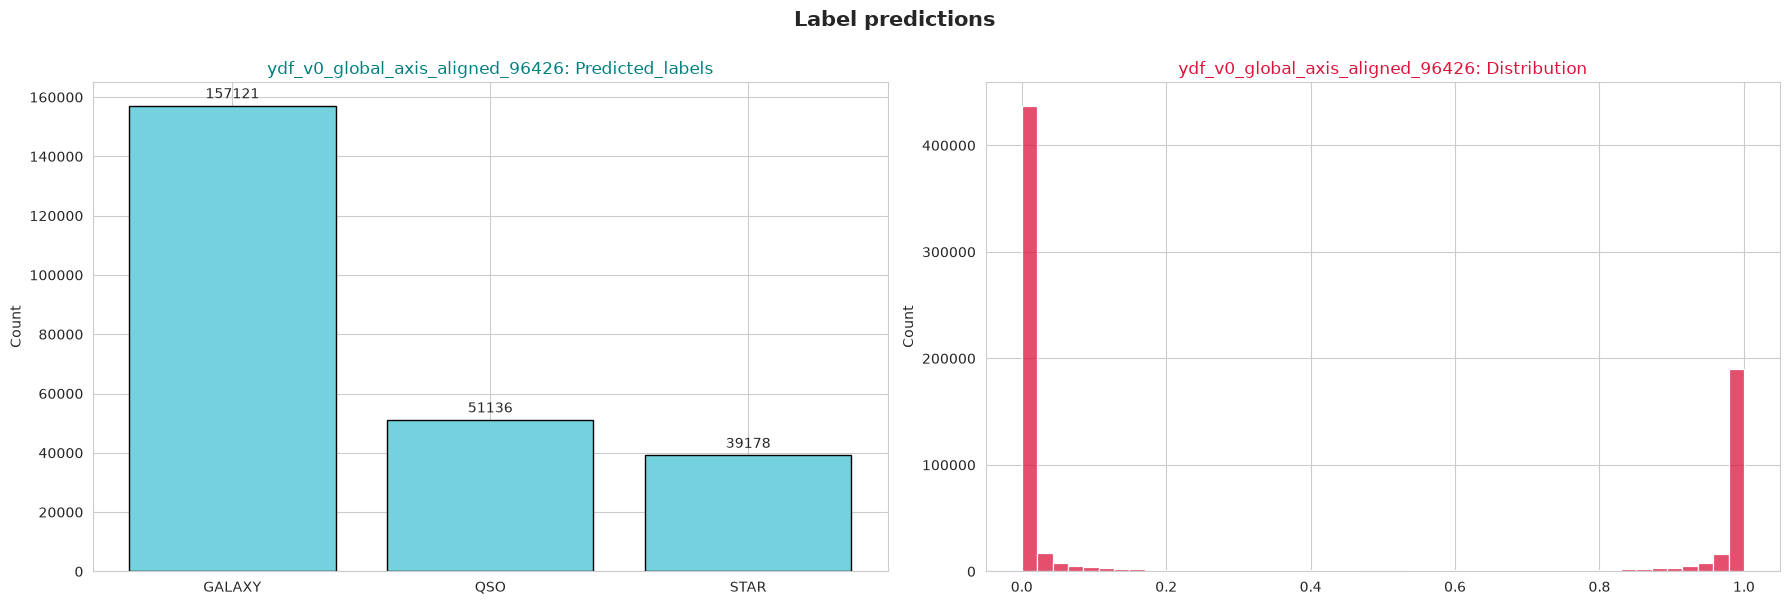


ydf_v0_global_sparse_oblique_96434 saved! (247435, 3)


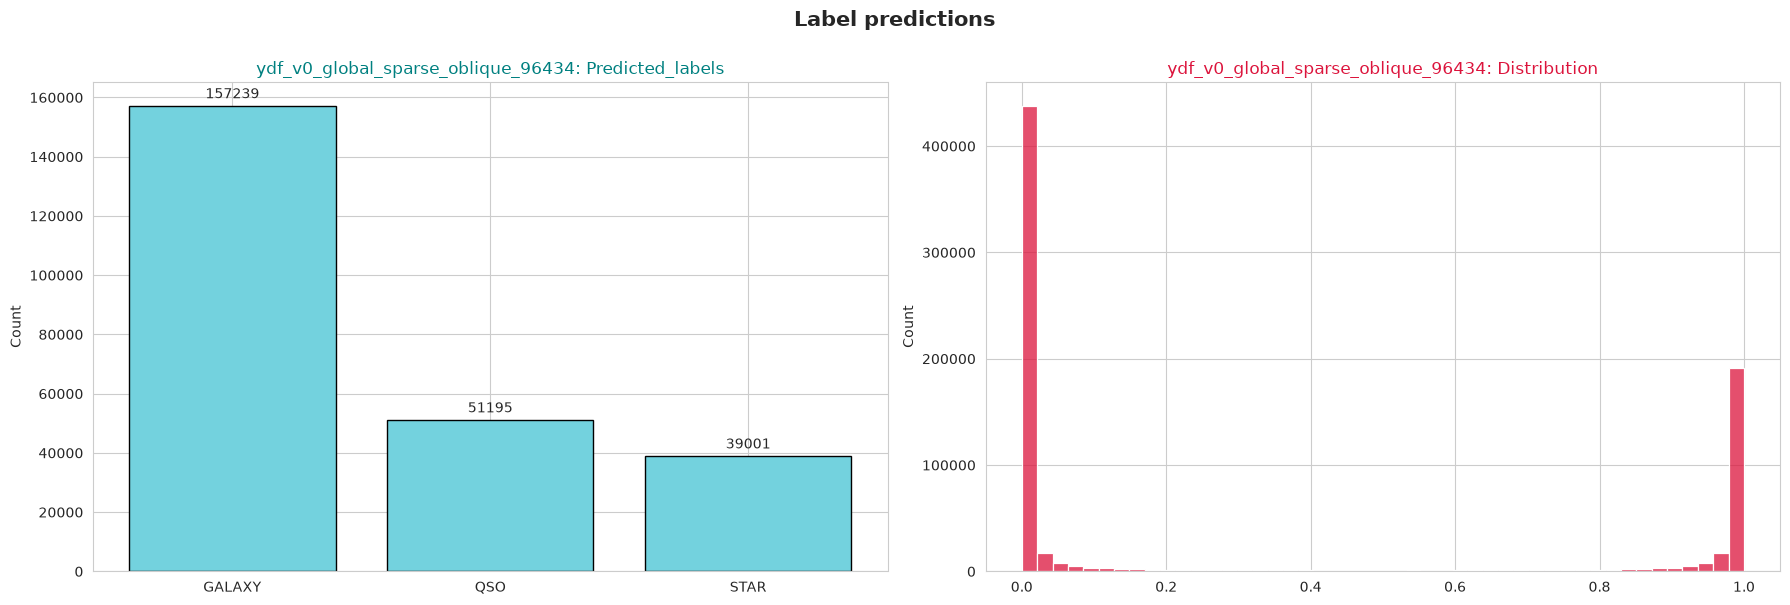

In [44]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(18, 6))

            counts = [np.sum(y_labels == _) for _ in range(len(np.unique(y_labels)))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='crimson')
            axs[1].set_title(f"{n}: Distribution", color='crimson')
            
            plt.suptitle('Label predictions', fontsize=15, y=1.00, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [45]:
final_results = pd.DataFrame(model_results)
final_results

,ydf_v0_global_axis_aligned_96426,ydf_v0_global_sparse_oblique_96434
0,GALAXY,GALAXY
1,GALAXY,GALAXY
2,GALAXY,GALAXY
3,STAR,STAR
4,GALAXY,GALAXY
...,...,...
247430,QSO,QSO
247431,QSO,QSO
247432,GALAXY,GALAXY
247433,QSO,QSO


In [46]:
# try:
#     import shap
# except:
#     %pip install -q -U shap
#     import shap

# print(f"Shap version: {shap.__version__}")

In [47]:
# ## -- SHAP values: Feature Importances--
# knn_uni = all_model_predictions[list(all_model_predictions.keys())[0]]
# mlp_ann = all_model_predictions[list(all_model_predictions.keys())[-1]]
# max_display = 20

# for i, m in enumerate([knn_uni, mlp_ann]):
#     model = m['model']
#     x_train = m['data'][0]
#     x_train = m['data'][1]

#     ## -- Shap Explainer --
#     def f(x):
#         return model.predict_proba(x)[:, 1]

#     x_med = x_train.median().values.reshape((1, x_train.shape[1]))
#     explainer = shap.Explainer(f, x_med)
#     explanation = explainer(x_valid.iloc[:1000])

#     ## -- Bar plot --
#     plt.subplot(121)
#     shap.plots.bar(explanation[0], max_display=max_display, show=False)
#     plt.title('Bar - Overall impact on model predictions')
    
#     ## -- Beeswarm plot --
#     plt.subplot(122)
#     shap.plots.beeswarm(explanation, order=explanation.abs.max(0), plot_size=(18, 8),
#                         max_display=max_display, color_bar=False, show=False)
#     plt.title('Beeswarm - Most impactful features')

#     if i == 0:
#         plt.suptitle(list(all_model_predictions.keys())[i], fontweight='semibold')
#     else:
#         plt.suptitle(list(all_model_predictions.keys())[-1], fontweight='semibold')

#     plt.tight_layout(pad=1.5)
#     plt.show()
#     print()

In [48]:
## -- Get models & val_data for inspection --
all_data   = []
all_models = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'data':
            all_data.append(y)
        elif x == 'model':
            all_models.append(y)

print(f"⚙️ Inspecting first YDF model...\n")
all_models[0].analyze(all_data[0])

⚙️ Inspecting first YDF model...



In [49]:
# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'model':
#             print(f"\n|{'='*52}|")
#             print(f" Model Inpection: {k}  {'='*16}")
#             print(f"|{'='*52}|")
#             display(y.describe())
#             display(y.analyze(all_data[i]))
#             # display(y.plot_tree())
#             # break